# Benchmark: Last.fm recommender

This notebook compares the recommendations from our embedding model against an industry baseline ([Last.fm Album recommender](https://github.com/jamesemcnally/critical-listener/blob/main/lastfm-recommender/lastfm_recommender.md)). We compute metrics for the top-5 recommendations on shared query albums, incorporating additional data on artist and top tags.

Our evaluation is twofold. First, we want to understand how our recommendations **differ from** an industry-style recommender, using metrics like **disagreement** (e.g., Jaccard similarity) and **baseline recovery** (e.g., Hit Rate@K) to show that users get, at minimum, a distinct set of suggestions.

Second, we implement **beyond-accuracy** metrics to characterize these differences, especially around discovery. We start with **popularity bias** (skew toward mainstream albums), **repetition/hubness** (how often the same targets dominate across queries) and **reciprocity** (mutual recommendations). We then look at list quality with **diversity** (how varied each list is), **novelty** (how rarely a target appears across lists), and a **serendipity** proxy (relevant-but-obscure picks). Together, these show whether the embedding recommender offers a broader, less monocultural experience than Last.fm.

**Scope note:** our model recommends from a catalog of 40k albums, versus Last.fm's estimated 2.2+ million. This asymmetry means the comparison speaks to *behavioral differences*, not equivalent coverage or discovery power at Last.fm's scale.

In [79]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import numpy as np
import pandas as pd

sns.set_theme(style="darkgrid", palette="deep")

from bench_cache import DEFAULT_CACHE_DIR, prepare_bench
from metrics import BASELINE_COL, EMBEDDING_COL
from utils import album_target, top_hubs
from viz import (
    legend_recommenders,
    plot_baseline_recovery_hit_rate_bars,
    plot_baseline_recovery_precision_bars,
    plot_disagreement_jaccard_bars,
    plot_disagreement_overlap_stacked,
    plot_recommender_bars,
    plot_repetition_sweeps,
    plot_variant_bars,
    show_theme,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Preparation

Load catalog, embedding recs, and Last.fm baseline via `data_loader.py`, then match recs to baseline queries and precompute top-n subsets. 

Results are cached under `lastfm-bench/.bench_cache/`. Set `REFRESH_CACHE = True` only when source data or metric code changes.

In [80]:
# data
DATA_DIR = Path("../datasets")
BENCH_PATH = DATA_DIR / "lastfm_recommendations_all_top_listener.csv"
RECS_PATH = DATA_DIR / "final_recs.parquet"
CATALOG_PATH = DATA_DIR / "albums.csv"

# caching
CACHE_DIR = DEFAULT_CACHE_DIR
REFRESH_CACHE = False  # set True to recompute after data/code changes

TOP_N = 5 ## top-N recommendations

In [81]:
# generate metrics
bench = prepare_bench(
    CATALOG_PATH,
    RECS_PATH,
    BENCH_PATH,
    top_n=TOP_N,
    cache_dir=CACHE_DIR,
    refresh=REFRESH_CACHE,
)

metrics_df = bench["metrics_df"]
recs_n = bench["recs_n"]
baseline_n = bench["baseline_n"]
REC_SOURCES = [("embedding recs", recs_n), ("last.fm baseline", baseline_n)]

Loaded cached bench data from /home/lbarleta/erdos/critical-listener/evaluation/.bench_cache
  metrics_df: 363 rows
  recs @ n=5: 54,740 rows, 10,948 queries
  baseline @ n=5: 22,475 rows, 4,495 queries


## Disagreement

*How much do our recommendtions and the Last.fm baseline **disagree**?*

For each query present in both runs, we measure the overlap between the lists of albums, artists, and tags using **Jaccard similarity** (intersection over union). These metrics are **symmetric**.

| Metric | Field | Explanation |
|--------|-------|-------------|
| `mean_jaccard` | **List overlap** | Mean Jaccard between the two top-`n` lists per shared query. |
| `zero_overlap_share` | **No overlap** | Share of shared queries where the two lists share nothing. |
| `mean_jaccard_comparable` | **Comparable tag overlap** | Tag Jaccard on queries with ≥3 comparable tag slots per side (`tags_comparable`). |
| `comparable_query_share` | **Fair-comparison coverage** | Share of shared queries that qualify for the restricted measure. |

### Albums

Full-list Jaccard mixes catalog mismatch with true disagreement. **In-corpus** restricts to queries where both recommenders have enough `albums.csv` coverage at depth `n`.

In [82]:
show_theme(metrics_df, "disagreement", "albums", n=5)

,theme,variant,metric,n,embedding recs,last.fm baseline
301,disagreement,albums,any_overlap_share,5,0.034928,0.034928
303,disagreement,albums,comparable_query_share,5,0.034705,0.034705
299,disagreement,albums,mean_jaccard,5,0.004255,0.004255
302,disagreement,albums,n_comparable_queries,5,156.000000,156.000000
298,disagreement,albums,n_shared_queries,5,4495.000000,4495.000000
300,disagreement,albums,zero_overlap_share,5,0.965072,0.965072


### Artists

Distinct recommended **artists** within each query's top-`n` list. Often higher overlap than albums because one act can fill multiple album slots.

In [83]:
show_theme(metrics_df, "disagreement", "artists", n=5)


,theme,variant,metric,n,embedding recs,last.fm baseline
310,disagreement,artists,any_overlap_share,5,0.117019,0.117019
308,disagreement,artists,mean_jaccard,5,0.019241,0.019241
307,disagreement,artists,n_shared_queries,5,4495.000000,4495.000000
309,disagreement,artists,zero_overlap_share,5,0.882981,0.882981


### Tags

Tags are the union of `rec_tags` across each query's top-`n` list. **Comparable** requires both recommenders to have non-empty tags at the same rank, and at least **3** such slots per query (independent of `n`).


In [84]:
show_theme(metrics_df, "disagreement", "tags", n=5)


,theme,variant,metric,n,embedding recs,last.fm baseline
350,disagreement,tags,any_overlap_share,5,0.902634,0.902634
352,disagreement,tags,comparable_query_share,5,0.527516,0.527516
348,disagreement,tags,mean_jaccard,5,0.127816,0.127816
351,disagreement,tags,n_comparable_queries,5,2243.000000,2243.000000
347,disagreement,tags,n_shared_queries,5,4252.000000,4252.000000
349,disagreement,tags,zero_overlap_share,5,0.097366,0.097366


In [85]:
show_theme(metrics_df, "disagreement", "tags_comparable", n=5)

,theme,variant,metric,n,embedding recs,last.fm baseline
355,disagreement,tags_comparable,any_overlap_comparable_share,5,0.946946,0.946946
353,disagreement,tags_comparable,mean_jaccard_comparable,5,0.139277,0.139277
354,disagreement,tags_comparable,zero_overlap_comparable_share,5,0.053054,0.053054


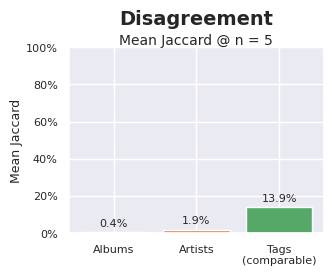

In [86]:
plot_disagreement_jaccard_bars(metrics_df, n=TOP_N, figsize=(3, 3))

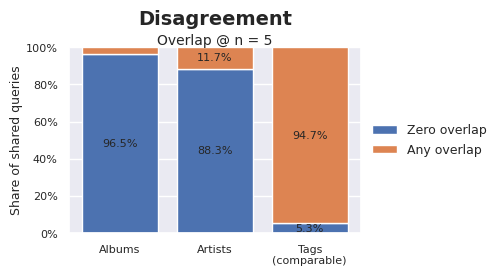

In [ ]:
plot_disagreement_overlap_stacked(metrics_df, n=TOP_N, figsize=(4, 3))


## Baseline Recovery (Hit Rate, Precision, and Recall)

Classic overlap metrics treating **Last.fm as the reference** and scoring whether embedding recs recover the same albums @k (on shared queries).

- **Precision@n** — share of embedding top-n that appear in Last.fm top-n.
- **Recall@n** — share of Last.fm top-n recovered by embedding.
- **Hit rate@n** — share of queries with any overlap.

Also report **in-corpus** agreement (fairer when Last.fm recommends out-of-index albums).


In [ ]:
show_theme(metrics_df, "agreement", n=[5])

,theme,variant,metric,n,embedding recs,last.fm baseline
166,agreement,full,hit_rate,5,0.034928,0.034928
167,agreement,full,mean_intersection,5,0.037597,0.037597
168,agreement,full,n_shared_queries,5,4495.000000,4495.000000
164,agreement,full,precision,5,0.007531,NaN
165,agreement,full,recall,5,NaN,0.007519
191,agreement,in_corpus,hit_rate,5,0.049611,0.049611
192,agreement,in_corpus,mean_intersection,5,0.053502,0.053502
193,agreement,in_corpus,n_shared_queries,5,3084.000000,3084.000000
189,agreement,in_corpus,precision,5,0.011257,NaN
190,agreement,in_corpus,recall,5,NaN,0.026827


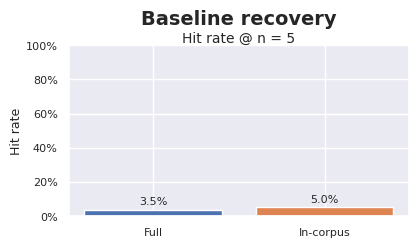

In [62]:
plot_baseline_recovery_hit_rate_bars(metrics_df, n=TOP_N)

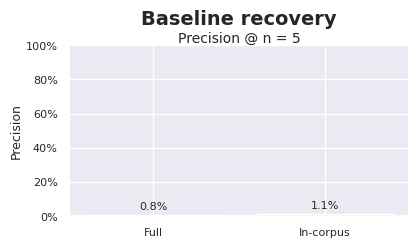

In [63]:
plot_baseline_recovery_precision_bars(metrics_df, n=TOP_N)

## Popularity bias

*To what extent recommendations skew toward **more popular** albums?*

Popularity bias measures how "popular" your recommended items are relative to some reference distribution, like the catalog. Here, we define popular in two ways: **review count** (how many reviews an album got) and **Last.fm listeners**.


| Metric | Field | Explanation |
|--------|-------|-------------|
| `mean_reviews_ratio` | **Review popularity** | Mean `review_count` of in-corpus recs ÷ catalog mean. >1 = bias toward well-reviewed albums. |
| `in_corpus_rec_share` | **In-corpus coverage** | Share of rec slots landing in `albums.csv`. Needed to interpret review-count stats. |
| `median_rec_query_ratio` | **Rec vs query** | Median rec listeners ÷ query listeners (+1 smoothed). >1 = recs more popular than the seed album. |
| `rec_more_popular_share` | **Upscale picks** | Share of comparable slots where the rec has more Last.fm listeners than the query. |

In [67]:
show_theme(metrics_df, "popularity")

,theme,variant,metric,n,embedding recs,last.fm baseline
237,popularity,listeners,catalog_listener_coverage,5,0.449797,0.449797
238,popularity,listeners,mean_listeners_catalog,5,179630.568046,179630.568046
239,popularity,listeners,median_query_listeners,5,47570.000000,47570.000000
240,popularity,listeners,median_rec_catalog_ratio,5,0.353938,0.363268
241,popularity,listeners,median_rec_listeners,5,63578.000000,65254.000000
242,popularity,listeners,median_rec_query_ratio,5,1.170069,1.265406
243,popularity,listeners,n_comparable_slots,5,12419.000000,12419.000000
244,popularity,listeners,n_rows_with_data,5,12419.000000,12419.000000
245,popularity,listeners,rec_more_popular_share,5,0.526935,0.555278
231,popularity,reviews,catalog_3plus_share,5,0.001638,0.001638


/home/lbarleta/erdos/critical-listener/lastfm-bench/viz.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/home/lbarleta/erdos/critical-listener/lastfm-bench/viz.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/home/lbarleta/erdos/critical-listener/lastfm-bench/viz.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")


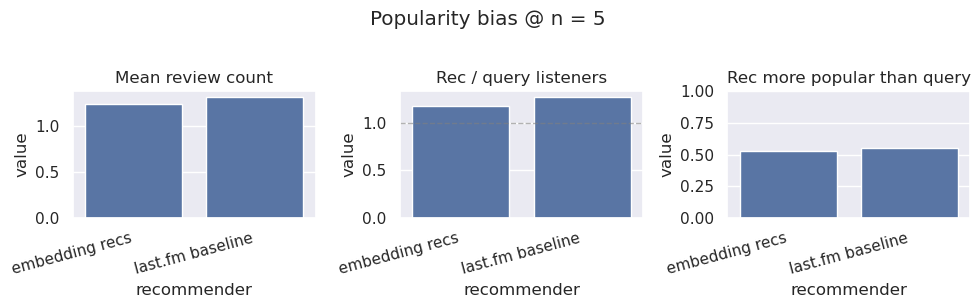

In [68]:
sub = show_theme(metrics_df, "popularity", n=TOP_N)

panels = [
    ("reviews", "mean_reviews_recs", "Mean review count", None, None),
    ("listeners", "median_rec_query_ratio", "Rec / query listeners", None, 1.0),
    ("listeners", "rec_more_popular_share", "Rec more popular than query", (0, 1), None),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (variant, metric, title, ylim, hline) in zip(axes, panels):
    row = sub[(sub["variant"] == variant) & (sub["metric"] == metric)].iloc[0]
    plot_recommender_bars(ax, row, title=title, ylim=ylim, hline=hline)

fig.suptitle(f"Popularity bias @ n = {TOP_N}", y=1.02)

plt.tight_layout()
plt.show()

## Repetition & hubness

When many unrelated query albums receive the **same** recommended target, that target is a **hub**. Hubness measures how much the recommender recycles the same targets across different queries — distinct from **within-list diversity** (Diversity).

| Metric | Field | Explanation |
|--------|-------|-------------|
| `unique_share` | **Global coverage** | Among all recommendation slots, the share filled by *distinct* targets: distinct targets ÷ total slots. |
| `hub_slot_share` | **Slot-level recycling** | Share of all recommendation slots whose target was already recommended to at least one *other* query. Answers: "what fraction of picks are repeat appearances of a cross-query favorite?" |
| `hub_share` | **Target-level recycling** | Share of *distinct* recommended targets that appear in 2+ queries' lists. A few mega-hubs can dominate many slots without most unique targets being repeated — so this can diverge from `hub_slot_share`. |
| `gini` | **Concentration shape** | How unequally slots are distributed across targets (0 = even spread; 1 = one target gets everything). High Gini + moderate `hub_share` → a few super-hubs dominate; high Gini + high `hub_share` → repetition is both broad and skewed. |
| `top1pct_concentration` | **Head concentration** | Share of slots filled by the top 1% most-frequent targets. Captures whether a thin elite of mega-hubs accounts for most recommendations. |

The embedding model draws from a **smaller catalog** than Last.fm, so higher hubness is expected.


### Albums

Hubs are normalized `artist::album` keys. At each `n`, see the sweep table plus headline stats for `n = 1` and `n = TOP_N`.


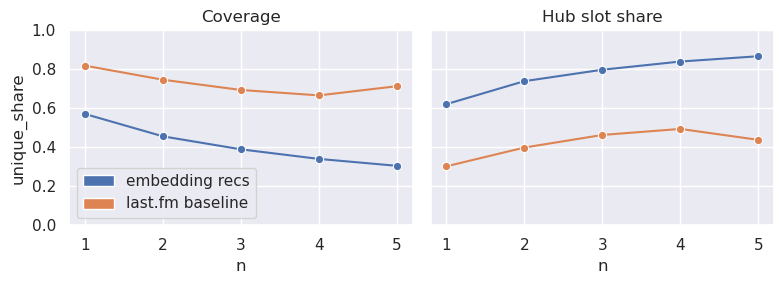

In [55]:
plot_repetition_sweeps(metrics_df, "albums")

In [56]:
show_theme(metrics_df, "repetition", "albums", n=[5])

,theme,variant,metric,n,embedding recs,last.fm baseline
36,repetition,albums,gini,5,0.513879,0.247125
37,repetition,albums,hub_share,5,0.564298,0.212509
38,repetition,albums,hub_slot_share,5,0.867172,0.438087
39,repetition,albums,n_hubs,5,9417.000000,3408.000000
40,repetition,albums,n_queries,5,10948.000000,4495.000000
41,repetition,albums,n_total,5,54740.000000,22475.000000
42,repetition,albums,n_unique,5,16688.000000,16037.000000
43,repetition,albums,top1pct_concentration,5,0.128553,0.060067
44,repetition,albums,unique_share,5,0.304859,0.713548


In [57]:
print(f"Top album hubs at n = {TOP_N}:")
for label, df in REC_SOURCES:
    print(f"\n[{label}]")
    print(top_hubs(df, album_target, k=8))

Top album hubs at n = 5:

[embedding recs]
the music::the music                            365
the music::strength in numbers                  217
woo::awaawaa                                    188
shimmer::and i revel                            148
post animal::when i think of you in a castle    132
these are powers::terrific seasons              115
the drums::the drums                            108
themselves::crownsdown                          105
Name: query_count, dtype: int64

[last.fm baseline]
queen::greatest hits                21
queen::a reality tour               17
editors::the back room              16
bloc party::silent alarm            15
franz ferdinand::franz ferdinand    15
great lake swimmers::ongiara        14
elton john::greatest hits           14
jose gonzalez::veneer               13
Name: query_count, dtype: int64


### Artists

Same hubness sweep on normalized **artist** names. Artist hub counts are usually higher than album hub counts because one act can appear on many albums.


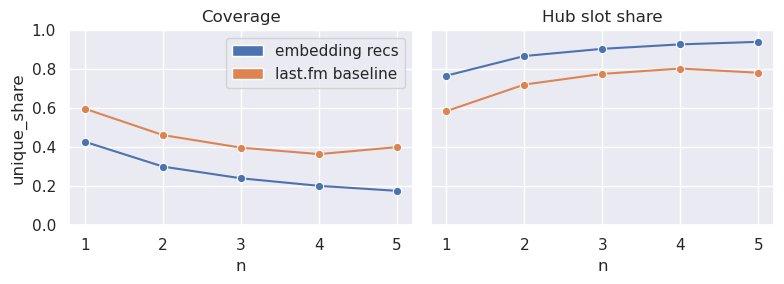

In [58]:
plot_repetition_sweeps(metrics_df, "artists")

In [59]:
show_theme(metrics_df, "repetition", "artists", n=[5])

,theme,variant,metric,n,embedding recs,last.fm baseline
81,repetition,artists,gini,5,0.609325,0.461559
82,repetition,artists,hub_share,5,0.665666,0.456978
83,repetition,artists,hub_slot_share,5,0.940994,0.782380
84,repetition,artists,n_hubs,5,6431.000000,4116.000000
85,repetition,artists,n_queries,5,10948.000000,4495.000000
86,repetition,artists,n_total,5,54740.000000,22475.000000
87,repetition,artists,n_unique,5,9661.000000,9007.000000
88,repetition,artists,top1pct_concentration,5,0.162203,0.092859
89,repetition,artists,unique_share,5,0.176489,0.400756


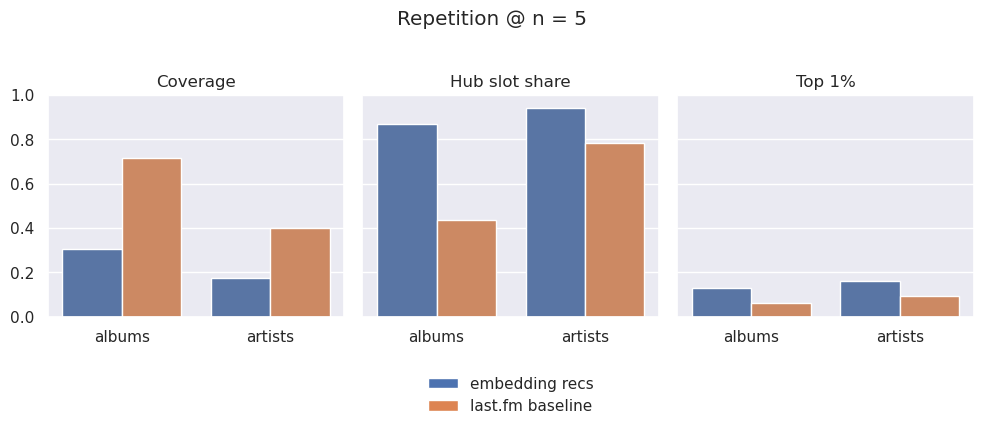

In [60]:
metrics = ["unique_share", "hub_slot_share", "top1pct_concentration"]
titles = {
    "unique_share": "Coverage",
    "hub_slot_share": "Hub slot share",
    "top1pct_concentration": "Top 1%",
}
sub = show_theme(metrics_df, "repetition", n=TOP_N).query(
    "metric in @metrics and variant in ['albums', 'artists']"
)

fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True)
for ax, metric in zip(axes, metrics):
    chunk = sub[sub["metric"] == metric].set_index("variant").loc[["albums", "artists"]]
    plot_variant_bars(ax, chunk, title=titles[metric])

fig.suptitle(f"Repetition @ n = {TOP_N}", y=1.02)
legend_recommenders(fig.axes[1], loc="lower center", bbox_to_anchor=(0.5, -0.5), ncol=1, frameon=False)

plt.tight_layout()
plt.show()

## Reciprocity

If artist A recommends artist B, does B recommend A back?

Each recommendation is a directed **edge**; a reciprocal pair `(A→B, B→A)` means mutual pointing. High reciprocity suggests **closed neighborhoods**.

In [64]:
show_theme(metrics_df, "reciprocity")


,theme,variant,metric,n,embedding recs,last.fm baseline
207,reciprocity,albums,n_edges,5,54698.000000,22474.000000
208,reciprocity,albums,n_reciprocal,5,5969.000000,180.000000
209,reciprocity,albums,reciprocal_rate,5,0.109126,0.008009
210,reciprocity,artists,n_edges,5,40848.000000,17275.000000
211,reciprocity,artists,n_reciprocal,5,5062.000000,862.000000
212,reciprocity,artists,reciprocal_rate,5,0.123923,0.049899


## Diversity

How spread out is each query's top-N list **within that list**? Each metric is computed per query, then averaged across queries.

| Metric | Field | Explanation |
|--------|-------|-------------|
| `mean_unique` | **List breadth** | Average count of distinct artists or tags in a query's list. |
| `mean_diversity_ratio` | **Within-list spread** | Distinct targets ÷ list length (1.0 = no repeats in that list). |
| `all_distinct_share` | **Fully diverse lists** | Share of queries where every slot is a different target. |
| `single_target_share` | **Mono lists** | Share of queries where all slots collapse to one artist or tag. |

Album diversity is omitted — with top-5 lists, distinct albums per query is ~100% for both recommenders. **Artist** and **tag** diversity are more informative below.


In [ ]:
show_theme(metrics_df, "diversity")



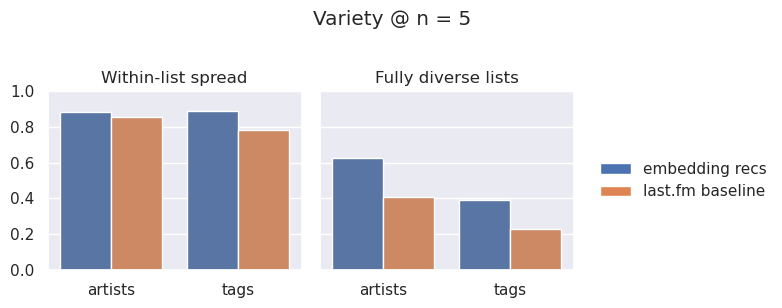

In [63]:
metrics = ["mean_diversity_ratio", "all_distinct_share"]
titles = {
    "mean_diversity_ratio": "Within-list spread",
    "all_distinct_share": "Fully diverse lists",
}
sub = show_theme(metrics_df, "diversity", n=TOP_N).query(
    "metric in @metrics and variant in ['artists', 'tags']"
)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
for ax, metric in zip(axes, metrics):
    chunk = sub[sub["metric"] == metric].set_index("variant").loc[["artists", "tags"]]
    plot_variant_bars(ax, chunk, title=titles[metric])

fig.suptitle(f"Diversity @ n = {TOP_N}", y=1.02)
legend_recommenders(fig.axes[1], loc="center left", bbox_to_anchor=(1.05, 0.5), ncol=1, frameon=False)

plt.tight_layout()
plt.show()


## Novelty

How uncommon are recommendations **across query lists**? Each rec slot is scored by how many query lists contain that target (**reach**). 

**Self-information** (surprise) here is a slot-level surprise score based on how often that target appears across the run, normalized by number of query lists 

| Metric | Field | Explanation |
|--------|-------|-------------|
| `mean_reach` | **List reach** | Average number of query lists each recommended target appears in. Lower = it surfaces for fewer queries. |
| `singleton_share` | **One-list recs** | Share of rec slots where the target appears on exactly one query list. |
| `mean_novelty` | **Normalized surprise** | Self-information scaled to 0–1 (1 = target unique to one list). Easier to compare than raw bits. |
| `effective_catalog` | **Spread diversity** | Distinct targets implied if recs were spread uniformly across the run. Higher = more distinct targets in practice. |

In [65]:
show_theme(metrics_df, "novelty")

,theme,variant,metric,n,embedding recs,last.fm baseline
213,novelty,albums,effective_catalog,5,9352.095570,13418.627297
214,novelty,albums,mean_novelty,5,0.810019,0.938678
215,novelty,albums,mean_reach,5,14.925100,2.228476
216,novelty,albums,mean_self_information,5,10.869146,11.390021
217,novelty,albums,median_novelty,5,0.826959,1.000000
218,novelty,albums,median_reach,5,5.000000,1.000000
219,novelty,albums,median_self_information,5,11.096452,12.134105
220,novelty,albums,n_lists,5,10948.000000,4495.000000
221,novelty,albums,singleton_share,5,0.132828,0.561913
222,novelty,artists,effective_catalog,5,4107.859157,5777.564795


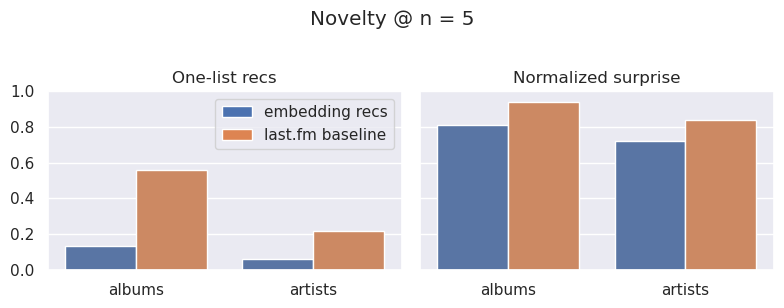

In [66]:
# Novelty summary at n = TOP_N (album vs artist level)
metrics = ["singleton_share", "mean_novelty"]
titles = {
    "singleton_share": "One-list recs",
    "mean_novelty": "Normalized surprise",
}
sub = show_theme(metrics_df, "novelty", n=TOP_N).query(
    "metric in @metrics and variant in ['albums', 'artists']"
)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
for ax, metric in zip(axes, metrics):
    chunk = sub[sub["metric"] == metric].set_index("variant").loc[["albums", "artists"]]
    plot_variant_bars(ax, chunk, title=titles[metric])

fig.suptitle(f"Novelty @ n = {TOP_N}", y=1.02)
legend_recommenders(axes[0])

plt.tight_layout()
plt.show()

## Serendipity

How often are recs **relevant but not obvious**? This is a **rough proxy** — not full serendipity (which also needs user surprise and a stronger relevance model). Each **rec slot** is scored independently.

**Definition:** a slot counts as *serendipitous* when both hold:
1. **Not obvious** — recommended artist ≠ query artist (filters same-artist echo picks).
2. **Obscure** — popularity is at or below the catalog median (`review_count` for the review-count variant; `rec_listeners` for the listener variant).

We do **not** model user expectations directly; obscurity stands in for "non-obvious." Relevance is approximated only by the different-artist filter.

We measure obscurity two ways:
- **Review count** (`albums.csv`)
- **Last.fm listeners** (comparable slots where both recommenders have listener data)

| Metric | Field | Explanation |
|--------|-------|-------------|
| `catalog_median_review_count` | **Review threshold** | Median `review_count` in the catalog (obscurity cutoff for review-count variant). |
| `in_corpus_share` | **In-corpus coverage** | Share of rec slots whose album appears in `albums.csv` (has `review_count`). |
| `serendipitous_share` | **Serendipitous (all slots)** | Different artist **and** `review_count` ≤ catalog median. |
| `serendipitous_in_corpus_share` | **Serendipitous (in-corpus)** | In-corpus slots only: different artist **and** `review_count` ≤ catalog median. |
| `catalog_median_listeners` | **Listener threshold** | Median `listeners` in the catalog (obscurity cutoff for listener variant). |
| `n_comparable_slots` | **Comparable slots** | Slots where both recommenders have listener data. |
| `serendipitous_listener_share` | **Serendipitous (listeners)** | Comparable slots: different artist **and** `rec_listeners` ≤ catalog median. |

**How to read:** compare rates on the same denominator. Review-count **all-slots** rates are dominated by in-corpus coverage (~95% emb vs ~31% Last.fm). Prefer `serendipitous_in_corpus_share` for a fair review-count comparison. Listener rates use comparable overlap only — check `n_comparable_slots`.


In [73]:
show_theme(metrics_df, "serendipity")


,theme,variant,metric,n,embedding recs,last.fm baseline
360,serendipity,listeners,catalog_median_listeners,5,37619.500000,37619.500000
361,serendipity,listeners,n_comparable_slots,5,12419.000000,12419.000000
362,serendipity,listeners,serendipitous_listener_share,5,0.391255,0.412030
356,serendipity,reviews,catalog_median_review_count,5,1.000000,1.000000
357,serendipity,reviews,in_corpus_share,5,0.949781,0.305139
358,serendipity,reviews,serendipitous_in_corpus_share,5,0.767517,0.700058
359,serendipity,reviews,serendipitous_share,5,0.728973,0.213615


/home/lbarleta/erdos/critical-listener/lastfm-bench/viz.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/home/lbarleta/erdos/critical-listener/lastfm-bench/viz.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
/home/lbarleta/erdos/critical-listener/lastfm-bench/viz.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")


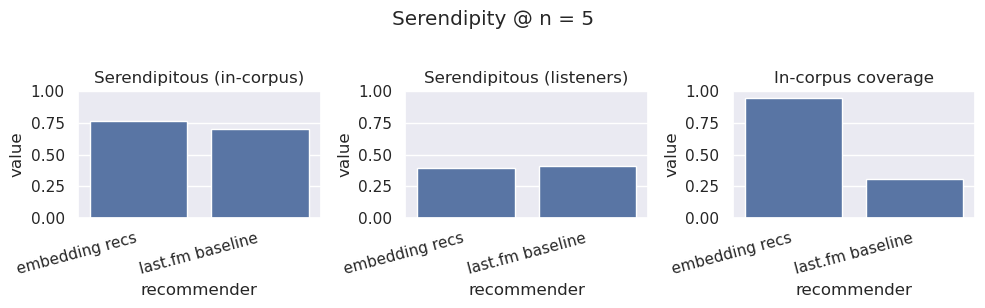

In [75]:
sub = show_theme(metrics_df, "serendipity", n=TOP_N)

panels = [
    ("reviews", "serendipitous_in_corpus_share", "Serendipitous (in-corpus)", (0, 1)),
    ("listeners", "serendipitous_listener_share", "Serendipitous (listeners)", (0, 1)),
    ("reviews", "in_corpus_share", "In-corpus coverage", (0, 1)),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (variant, metric, title, ylim) in zip(axes, panels):
    row = sub[(sub["variant"] == variant) & (sub["metric"] == metric)].iloc[0]
    plot_recommender_bars(ax, row, title=title, ylim=ylim)

fig.suptitle(f"Serendipity @ n = {TOP_N}", y=1.02)
plt.tight_layout()
plt.show()